In [14]:
# Swaron ka 'Mean' nikalna (Shruti detection)
# Hum 100, 200, 300... ke paas ke data ko group karenge
from scipy.stats import binned_statistic

bins = np.arange(0, 1200, 10) # 10 cents ka resolution
means, bin_edges, _ = binned_statistic(cents_ts[cents_ts > 0], cents_ts[cents_ts > 0], statistic='mean', bins=bins)

print("Tumhare gaaye hue swaron ka average Cent-value:")
print(means)

Tumhare gaaye hue swaron ka average Cent-value:
[   6.10789844   16.10789844   26.10789844   36.10789844   46.10789844
   56.10789844   66.10789844   76.10789844   86.10789844   96.10789844
  106.10789844  116.10789844  126.10789844  136.10789844  146.10789844
  156.10789844  166.10789844  176.10789844  186.10789844  196.10789844
  206.10789844  216.10789844  226.10789844  236.10789844  246.10789844
  256.10789844  266.10789844  276.10789844  286.10789844  296.10789844
  306.10789844  316.10789844  326.10789844  336.10789844  346.10789844
  356.10789844  366.10789844  376.10789844  386.10789844  396.10789844
  406.10789844  416.10789844  426.10789844  436.10789844  446.10789844
  456.10789844  466.10789844  476.10789844  486.10789844  496.10789844
  506.10789844  516.10789844  526.10789844  536.10789844  546.10789844
  556.10789844  566.10789844  576.10789844  586.10789844  596.10789844
  606.10789844  616.10789844  626.10789844  636.10789844  646.10789844
  656.10789844  666.10789844 

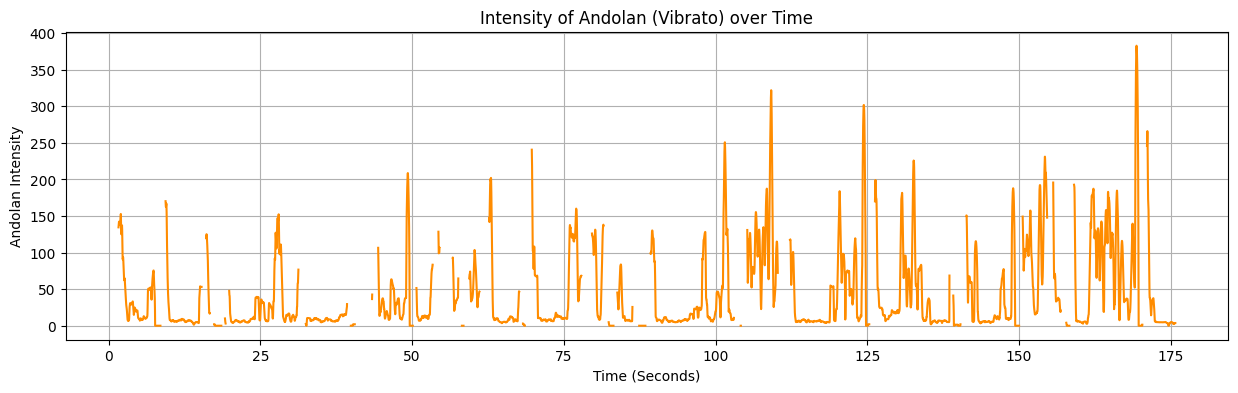

In [13]:
import pandas as pd

# Pandas series mein convert karke rolling std dev nikalna
s = pd.Series(cents_ts)
# 50-frame ka rolling window (approx 1 second)
andolan_intensity = s.rolling(window=50).std()

plt.figure(figsize=(15, 4))
plt.plot(times, andolan_intensity, color='darkorange')
plt.title("Intensity of Andolan (Vibrato) over Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Andolan Intensity")
plt.grid(True)
plt.show()

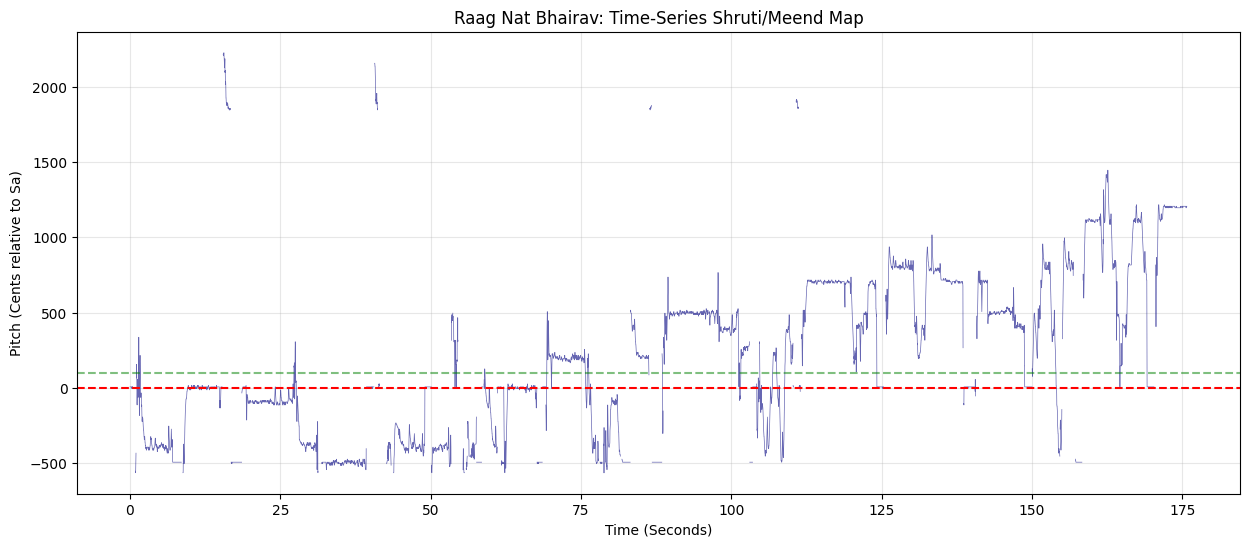

In [11]:
# pYIN mein hamare paas 'time_frames' bhi hote hain
# Librosa frames_to_time function ka use karega
times = librosa.frames_to_time(np.arange(len(f0)), sr=sr)

# Pitch array ko cents mein convert karna
cents_ts = 1200 * np.log2(f0 / sa_freq)
# Note: yahan modulo % 1200 mat lagana, taaki 'glide' (Meend) upar-neeche dikh sake

# Plotting the Time-Series
plt.figure(figsize=(15, 6))
plt.plot(times, cents_ts, color='navy', alpha=0.6, linewidth=0.5)

plt.title("Raag Nat Bhairav: Time-Series Shruti/Meend Map")
plt.xlabel("Time (Seconds)")
plt.ylabel("Pitch (Cents relative to Sa)")
plt.axhline(0, color='red', linestyle='--') # Sa
plt.axhline(100, color='green', linestyle='--', alpha=0.5) # Komal Re reference
plt.grid(True, alpha=0.3)

plt.show()

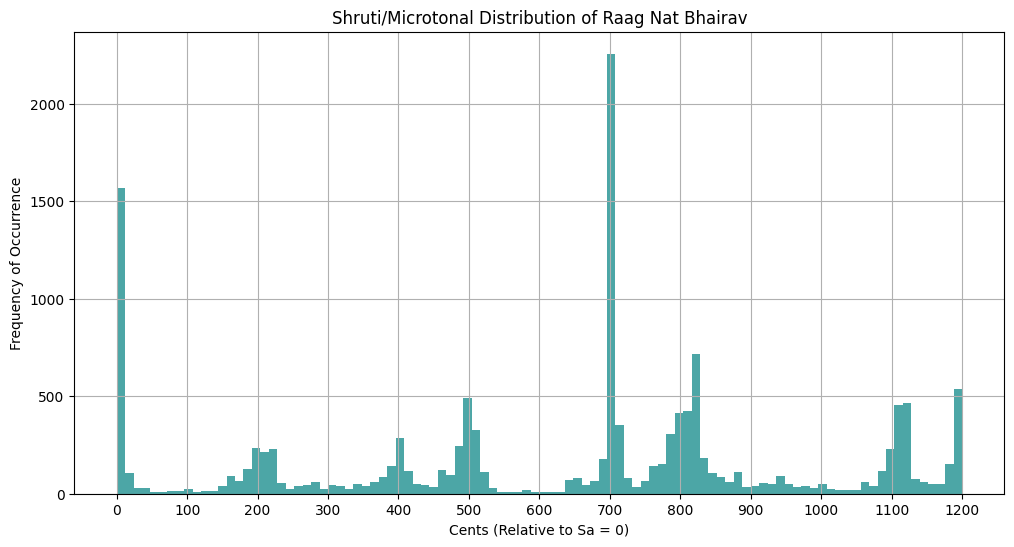

In [10]:
# Hz to Cents Conversion
cents_values = 1200 * np.log2(pitch_values / sa_freq)

# Cents ko 0-1200 ke range mein laana (modulo 1200)
cents_values = cents_values % 1200

# Histogram plot karna
plt.figure(figsize=(12, 6))
plt.hist(cents_values, bins=100, range=(0, 1200), color='teal', alpha=0.7)
plt.title("Shruti/Microtonal Distribution of Raag Nat Bhairav")
plt.xlabel("Cents (Relative to Sa = 0)")
plt.ylabel("Frequency of Occurrence")
plt.xticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200])
plt.grid(True)
plt.show()

In [8]:
# Mode nikalna (Most frequent frequency)
# Histogram ka use karke peak frequency dhundhna
counts, bin_edges = np.histogram(pitch_values, bins=500)
sa_freq = bin_edges[np.argmax(counts)]

print(f"Detected Tonic 'Sa' = {sa_freq:.2f} Hz")

Detected Tonic 'Sa' = 138.50 Hz


In [7]:
# pYIN algorithm (Probabilistic YIN)
# fmin: 100Hz (Male voice ke liye safe)
# fmax: 800Hz (Bhairav ke unche swaron ke liye)
f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=100, fmax=800, sr=sr)

# Pitch array se NaN (silence) hatao taaki sirf gaane ki frequencies bachein
pitch_values = f0[~np.isnan(f0)]

print(f"Total pitch points extracted: {len(pitch_values)}")
print(f"Sample of extracted frequencies (Hz): {pitch_values[:10]}")

Total pitch points extracted: 14380
Sample of extracted frequencies (Hz): [138.99182198 138.99182198 138.99182198 138.99182198 138.99182198
 138.99182198 138.99182198 138.99182198 138.99182198 138.99182198]


In [6]:
# Convert M4A to WAV properly
!ffmpeg -i "nat_bhairav_sample.m4a" "nat_bhairav.wav"

# Ab isi WAV file ko load karenge
y, sr = librosa.load("nat_bhairav.wav", sr=44100)
print(f"Success! Signal shape: {y.shape}, Sampling Rate: {sr}")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [1]:
# Libraries check aur import
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

print("Libraries Imported Successfully!")

Libraries Imported Successfully!
